In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

c:\Users\manh\AppData\Local\Programs\Python\Python310\lib\site-packages\google\api_core\_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.11) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


In [2]:
df = pd.read_csv("./data/vn30_filtered.csv")
df

,symbol,time,close,volume,vnindex
0,ACB,2017-01-03,3.33,1609757,672.01
1,ACB,2017-01-04,3.35,739000,674.70
2,ACB,2017-01-05,3.35,471881,675.81
3,ACB,2017-01-06,3.53,1409824,679.80
4,ACB,2017-01-09,3.65,970791,682.57
...,...,...,...,...,...
53045,VRE,2025-12-25,32.25,17089700,1742.85
53046,VRE,2025-12-26,32.00,20927400,1729.80
53047,VRE,2025-12-29,33.20,7573400,1754.84
53048,VRE,2025-12-30,32.80,8839700,1766.90


# Add feature

In [3]:
def _get_prefix(col_name):
    mapping = {
        "close": "stock",
        "vnindex": "market",
        "stock_lret_1": "stock",
        "market_lret_1": "market",
    }

    return mapping.get(col_name, col_name)

In [4]:
def compute_log_return(
    df=None,
    computed_cols=["close", "vnindex"],
    shifts=[1],
    group_col="symbol",
    time_col="time"
):
    df = df.copy()

    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(by=[group_col, time_col])

    for computed_col in computed_cols:
        df[computed_col] = df[computed_col].replace(0, np.nan)
        prefix = _get_prefix(computed_col)
        
        for shift in shifts:
            col_name = f"{prefix}_lret_{shift}"
            df[col_name] = (
                df.groupby(group_col)[computed_col].transform(
                    lambda x: np.log(x / x.shift(shift))
                )
            )

    return df

In [5]:
def compute_momentum(
    df=None,
    computed_cols=["stock_lret_1", "market_lret_1"],
    windows=[10, 20, 60],
    group_col="symbol",
    time_col="time"
):
    df = df.copy()

    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(by=[group_col, time_col])

    for computed_col in computed_cols:
        prefix = _get_prefix(computed_col)
        
        for window in windows:
            col_name = f"{prefix}_mom_{window}"
            df[col_name] = (
                df.groupby(group_col)[computed_col].transform(
                    lambda x: x.rolling(window).sum()
                )
            )

    return df

In [6]:
def compute_volatility(
    df=None,
    computed_cols=["stock_lret_1", "market_lret_1"],
    windows=[10, 20, 60],
    group_col="symbol",
    time_col="time"
):
    df = df.copy()

    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(by=[group_col, time_col])

    for computed_col in computed_cols:
        prefix = _get_prefix(computed_col)

        for window in windows:
            col_name = f"{prefix}_vol_{window}"
            df[col_name] = (
                df.groupby(group_col)[computed_col].transform(
                    lambda x: x.rolling(window).std()
                )
            )

    return df

In [7]:
def compute_beta(
    df=None,
    stock_col="stock_lret_1",
    market_col="market_lret_1",
    windows=[20, 60, 120],
    group_col="symbol",
    time_col="time"
):
    df = df.copy()

    df[time_col] = pd.to_datetime(df[time_col])

    df = df.sort_values(by=[group_col, time_col])

    for window in windows:
        beta_col = f"beta_{window}"

        df[beta_col] = (
            df.groupby(group_col).apply(
                lambda x: x[stock_col].rolling(window).cov(x[market_col]) / x[market_col].rolling(window).var()
            ).reset_index(level=0, drop=True)
        )

    return df

In [8]:
df2 = compute_log_return(df)
df3 = compute_momentum(df2)
df4 = compute_volatility(df3)
df5 = compute_beta(df4)

df5.head(30)

C:\Users\manh\AppData\Local\Temp\ipykernel_19168\3803840911.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(group_col).apply(
C:\Users\manh\AppData\Local\Temp\ipykernel_19168\3803840911.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby(group_col).apply(
C:\Users\manh\AppData\Local\Temp\ipykernel_19168\3803840911.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping column

,symbol,time,close,volume,vnindex,stock_lret_1,market_lret_1,stock_mom_10,stock_mom_20,stock_mom_60,...,market_mom_60,stock_vol_10,stock_vol_20,stock_vol_60,market_vol_10,market_vol_20,market_vol_60,beta_20,beta_60,beta_120
0,ACB,2017-01-03,3.33,1609757,672.01,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ACB,2017-01-04,3.35,739000,674.70,0.005988,0.003995,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ACB,2017-01-05,3.35,471881,675.81,0.000000,0.001644,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ACB,2017-01-06,3.53,1409824,679.80,0.052338,0.005887,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ACB,2017-01-09,3.65,970791,682.57,0.033429,0.004066,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ACB,2017-01-10,3.69,942499,681.07,0.010899,-0.002200,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ACB,2017-01-11,3.79,1447461,687.16,0.026740,0.008902,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ACB,2017-01-12,3.79,1158392,686.96,0.000000,-0.000291,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,ACB,2017-01-13,3.77,1230784,685.06,-0.005291,-0.002770,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,ACB,2017-01-16,3.83,575469,677.94,0.015790,-0.010448,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53050 entries, 0 to 53049
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   symbol         53050 non-null  object        
 1   time           53050 non-null  datetime64[ns]
 2   close          53050 non-null  float64       
 3   volume         53050 non-null  int64         
 4   vnindex        53050 non-null  float64       
 5   stock_lret_1   53026 non-null  float64       
 6   market_lret_1  53026 non-null  float64       
 7   stock_mom_10   52810 non-null  float64       
 8   stock_mom_20   52570 non-null  float64       
 9   stock_mom_60   51610 non-null  float64       
 10  market_mom_10  52810 non-null  float64       
 11  market_mom_20  52570 non-null  float64       
 12  market_mom_60  51610 non-null  float64       
 13  stock_vol_10   52810 non-null  float64       
 14  stock_vol_20   52570 non-null  float64       
 15  stock_vol_60   5161

In [10]:
df5.describe()

,time,close,volume,vnindex,stock_lret_1,market_lret_1,stock_mom_10,stock_mom_20,stock_mom_60,market_mom_10,...,market_mom_60,stock_vol_10,stock_vol_20,stock_vol_60,market_vol_10,market_vol_20,market_vol_60,beta_20,beta_60,beta_120
count,53050,53050.000000,5.305000e+04,53050.000000,53026.000000,53026.000000,52810.000000,52570.000000,51610.000000,52810.000000,...,51610.000000,52810.000000,52570.000000,51610.000000,52810.000000,52570.000000,51610.000000,52570.000000,51610.000000,50170.000000
mean,2021-07-29 02:04:42.028274944,37.428931,5.725899e+06,1120.909543,0.000656,0.000429,0.006476,0.012840,0.038372,0.004160,...,0.023537,0.018443,0.019043,0.019807,0.010194,0.010616,0.011229,1.067952,1.076127,1.082909
min,2017-01-03 00:00:00,1.390000,0.000000e+00,659.210000,-0.164622,-0.069639,-0.432595,-0.591249,-0.872745,-0.239379,...,-0.376093,0.000000,0.000000,0.000000,0.002093,0.002994,0.004493,-2.226469,-0.423859,-0.234362
25%,2019-05-20 00:00:00,12.570000,8.158465e+05,958.590000,-0.008925,-0.004084,-0.028722,-0.038376,-0.066983,-0.015654,...,-0.023744,0.011123,0.012289,0.014062,0.005916,0.006521,0.007299,0.699813,0.804873,0.863185
50%,2021-07-30 00:00:00,27.500000,2.207239e+06,1099.490000,0.000000,0.001419,0.004622,0.009390,0.024791,0.008762,...,0.027284,0.015800,0.017021,0.018415,0.008054,0.008796,0.010632,1.059299,1.078941,1.084410
75%,2023-10-17 00:00:00,57.310000,6.356198e+06,1269.930000,0.009903,0.006365,0.042255,0.064676,0.133740,0.028743,...,0.086711,0.023493,0.023741,0.024103,0.013203,0.013489,0.014404,1.411010,1.333393,1.314384
max,2025-12-31 00:00:00,219.100000,2.497607e+08,1784.490000,1.304007,0.280823,1.371445,1.386581,1.386581,0.289638,...,0.378491,0.413678,0.292446,0.169933,0.093494,0.065311,0.039490,5.137909,4.585177,4.502350
std,NaN,31.142643,1.011749e+07,233.814546,0.021763,0.012093,0.071065,0.101481,0.183261,0.041719,...,0.105436,0.011374,0.010384,0.008977,0.006281,0.005680,0.004555,0.580264,0.423510,0.379352


# Add label

In [11]:
def add_target(df, horizon=1):
    df = df.copy()
    df["target"] = df.groupby("symbol")["stock_lret_1"].shift(-horizon)
    df['target_time'] = df.groupby('symbol')['time'].shift(-horizon)
    df = df.dropna(subset=["target"])
    return df

In [12]:
df_output = add_target(df5)
df_output.info()

<class 'pandas.core.frame.DataFrame'>
Index: 53026 entries, 0 to 53048
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   symbol         53026 non-null  object        
 1   time           53026 non-null  datetime64[ns]
 2   close          53026 non-null  float64       
 3   volume         53026 non-null  int64         
 4   vnindex        53026 non-null  float64       
 5   stock_lret_1   53002 non-null  float64       
 6   market_lret_1  53002 non-null  float64       
 7   stock_mom_10   52786 non-null  float64       
 8   stock_mom_20   52546 non-null  float64       
 9   stock_mom_60   51586 non-null  float64       
 10  market_mom_10  52786 non-null  float64       
 11  market_mom_20  52546 non-null  float64       
 12  market_mom_60  51586 non-null  float64       
 13  stock_vol_10   52786 non-null  float64       
 14  stock_vol_20   52546 non-null  float64       
 15  stock_vol_60   51586 non

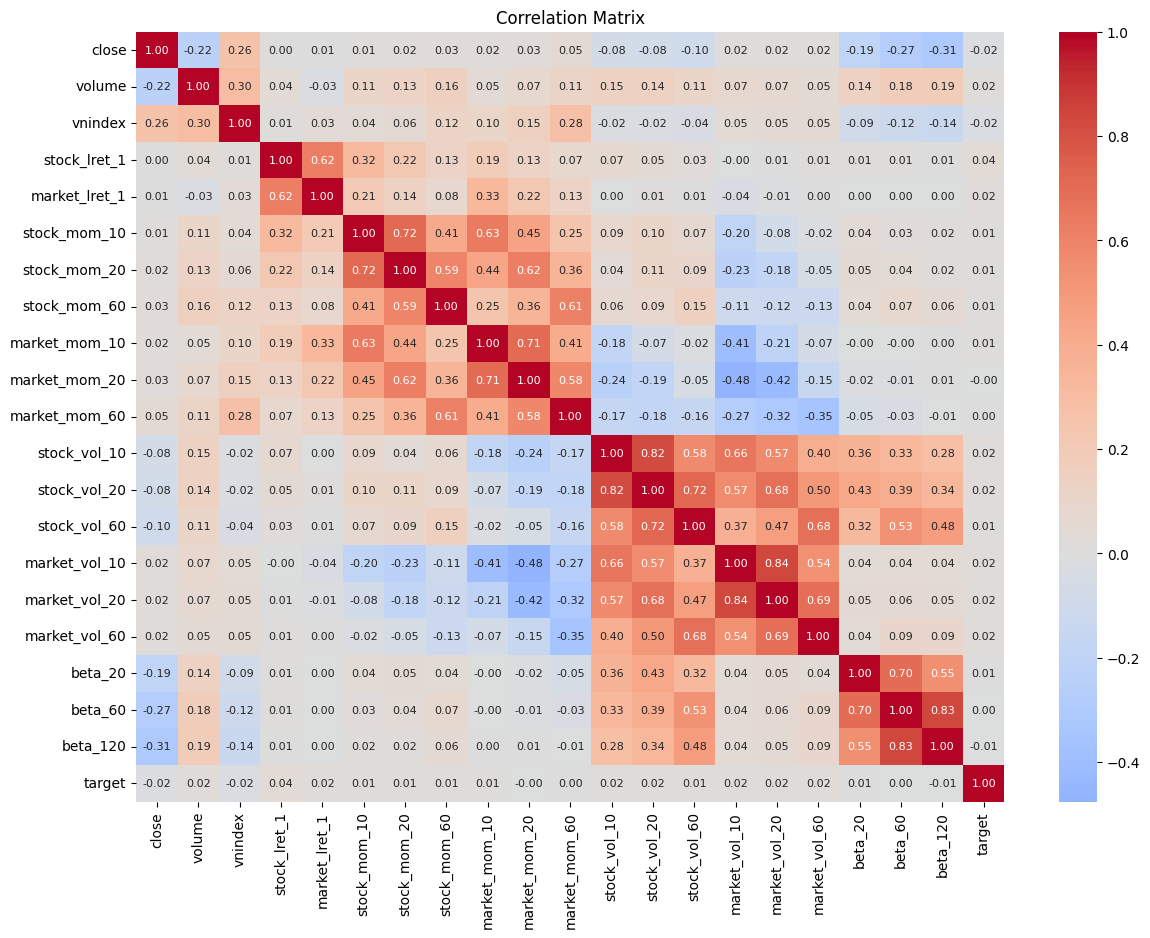

In [13]:
df_num = df_output.select_dtypes(include=["float64", "int64"])

corr = df_num.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,      
    fmt=".2f",       
    annot_kws={"size": 8}
)
plt.title("Correlation Matrix")
plt.show()

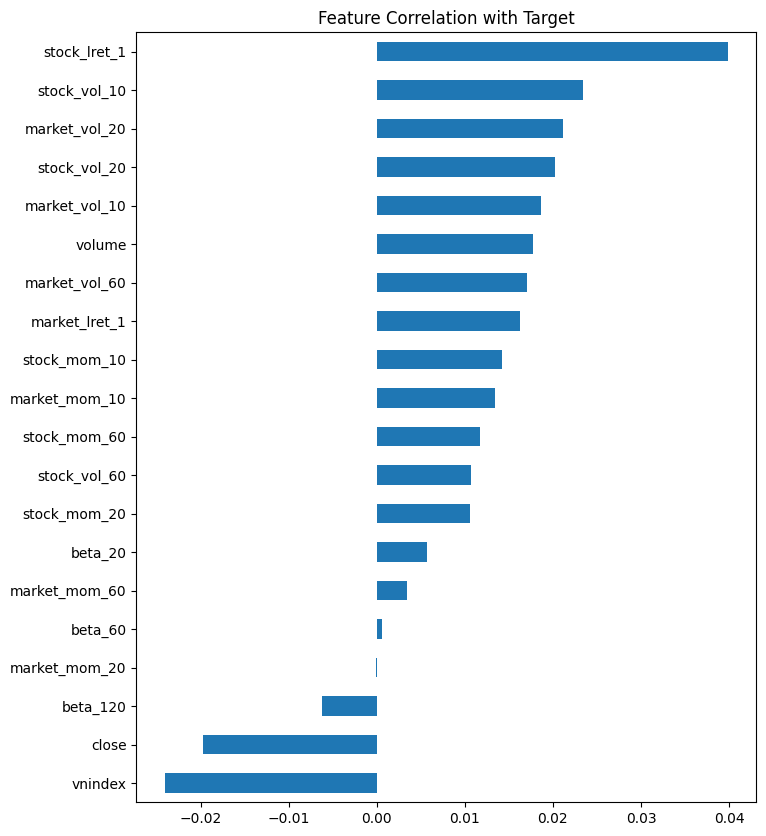

In [14]:
corr_target = df_num.corr()["target"].sort_values()

plt.figure(figsize=(8, 10))
corr_target.drop("target").plot(kind="barh")
plt.title("Feature Correlation with Target")
plt.show()

# Train/Val/Test

In [15]:
def split_time_series(df,
                      train_start='2018-01-01',
                      train_end='2023-01-01',
                      val_end='2024-01-01',
                      test_end=None,
                      time_col='time'):
    
    df = df.copy()

    train_df = df[
        (df[time_col] >= train_start) &
        (df[time_col] < train_end)
    ]

    val_df = df[
        (df[time_col] >= train_end) &
        (df[time_col] < val_end)
    ]

    if test_end is not None:
        test_df = df[
            (df[time_col] >= val_end) &
            (df[time_col] < test_end)
        ]
    else:
        test_df = df[df[time_col] >= val_end]

    return train_df, val_df, test_df

In [16]:
train_df, val_df, test_df = split_time_series(df3)
train_df.shape, val_df.shape, test_df.shape

((29881, 13), (5976, 13), (11976, 13))

In [17]:
print(train_df['time'].min(), train_df['time'].max())
print(val_df['time'].min(), val_df['time'].max())
print(test_df['time'].min(), test_df['time'].max())

2018-01-02 00:00:00 2022-12-30 00:00:00
2023-01-03 00:00:00 2023-12-29 00:00:00
2024-01-02 00:00:00 2025-12-31 00:00:00


In [18]:
print(train_df["symbol"].nunique())
print(val_df["symbol"].nunique())
print(test_df["symbol"].nunique())

24
24
24


In [19]:
set(test_df.symbol.unique()) - set(train_df.symbol.unique())

set()

In [20]:
symbols_in_train = train_df['symbol'].unique()

test_df = test_df[test_df['symbol'].isin(symbols_in_train)]

test_df['symbol'].nunique(), test_df.shape

(24, (11976, 13))

# Create sequences

In [21]:
def create_sequences(df, window=20, feature_col='log_return', target_col='target'):
    X, y, meta = [], [], [] 
    
    for symbol, sub_df in df.groupby('symbol'):
        sub_df = sub_df.sort_values('time').reset_index(drop=True)

        values_x = sub_df[feature_col].values
        values_y = sub_df[target_col].values
        
        for i in range(len(sub_df) - window):
            X.append(values_x[i : i + window])
            y.append(values_y[i + window - 1])
            meta.append({
                'symbol': symbol,
                'time': sub_df['target_time'].iloc[i + window - 1]
            })
    
    X = np.array(X).reshape(-1, window, 1)
    y = np.array(y)
    meta_df = pd.DataFrame(meta)
    
    return X, y, meta_df

In [22]:
X_train, y_train, meta_train = create_sequences(train_df)
X_train.shape, y_train.shape, meta_train.shape

KeyError: 'log_return'

In [ ]:
X_val, y_val, meta_val = create_sequences(val_df)
X_val.shape, y_val.shape, meta_val.shape

((5496, 20, 1), (5496,), (5496, 2))

In [ ]:
X_test, y_test, meta_test = create_sequences(test_df)
X_test.shape, y_test.shape, meta_test.shape

((11472, 20, 1), (11472,), (11472, 2))

In [ ]:
34511+20*29, 6641+20*29, 13862+20*29

(35091, 7221, 14442)

# Building LSTM